# Ejercicio guiado KMeans

## Ejercicio 1: Preparación del ambiente de trabajo

* Para este ejercicio trabajaremos de manera __conjunta__ identificando la paleta de colores de carátulas de álbumes.
    * Las imágenes se encuentran en una carpeta con el nombre `album_covers`
    * Cada imagen tiene la siguiente nomenclatura: `artista-nombre-del-album.jpg`.
* El objetivo es generar un método que nos permita identificar la dominancia de una cantidad finita de colores.
* Para importar imágenes y visualizarlas, vamos a importar las siguientes librerías:
    * Partamos por incluír las librerías clásicas: `pandas`, `numpy` y `matplotlib.pyplot`.
    * `sklearn.cluster.KMeans`: para extraer los principales componentes de una matriz numérica.
    * `skimage.io`: Para poder ingresar y leer imágenes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import seaborn as sns
import warnings
from sklearn.cluster import KMeans
import skimage.io as io
from sklearn.metrics import silhouette_score

warnings.filterwarnings(action="ignore")

## Ejercicio 2: Importación de imagenes

* Comencemos una imágen a nuestro ambiente de trabajo. Para ello ocuparemos `io.imread`. ¿Qué devuelve?
* Para visualizar la imágen en el notebook, ocupe `io.imshow`.

In [2]:
# Carga de imagen
cover = io.imread('album_covers/dua-lipa-self-titled.jpeg')
cover

array([[[122, 139, 182],
        [122, 139, 182],
        [123, 140, 183],
        ...,
        [229, 211, 233],
        [229, 211, 233],
        [229, 211, 233]],

       [[122, 139, 182],
        [123, 140, 183],
        [123, 140, 183],
        ...,
        [229, 211, 233],
        [229, 211, 233],
        [229, 211, 233]],

       [[123, 140, 183],
        [123, 140, 183],
        [124, 141, 184],
        ...,
        [229, 211, 233],
        [229, 211, 233],
        [229, 211, 233]],

       ...,

       [[ 66, 121, 175],
        [ 67, 122, 176],
        [ 67, 122, 176],
        ...,
        [186, 205, 247],
        [179, 198, 240],
        [181, 200, 240]],

       [[ 66, 121, 175],
        [ 67, 122, 176],
        [ 67, 122, 176],
        ...,
        [199, 217, 255],
        [161, 179, 219],
        [166, 184, 222]],

       [[ 66, 121, 175],
        [ 67, 122, 176],
        [ 67, 122, 176],
        ...,
        [212, 230, 255],
        [173, 191, 229],
        [131, 149, 187]]

In [3]:
# dimension de la imagen
cover.shape

(600, 600, 3)

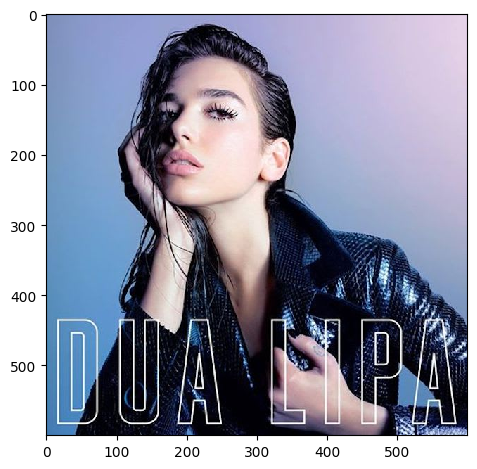

In [4]:
io.imshow('album_covers/dua-lipa-self-titled.jpeg')

## Ejercicio 3: Preprocesamiento de imágenes y KMeans

* Con la representación numérica de la imágen, vamos a extraer la altura, el ancho y la cantidad de canales mediante `shape`.
* Posteriormente redimensionaremos la imágen con `reshape`.
* Partamos por inicializar nuestro algoritmo `KMeans` con un `k=8`, ¿Qué significará esto?
* Vuelva a implementar el mismo algoritmo con `MiniBatchKMeans`. ¿Qué diferencia existe con `KMeans`?

In [5]:
# Guardamos los parametros de la imagen

h, w, ch = cover.shape
h, w, ch

(600, 600, 3)

In [6]:
# Se redimensiona la imagen a 2D para luego aplicar KMeans

d = cover.reshape(h*w, ch)
d.shape

(360000, 3)

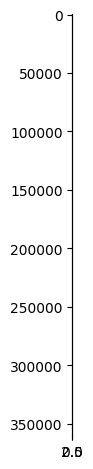

In [7]:
io.imshow(d)

In [8]:
%%time
# Aplicamos algoritmo de KMeans

k = KMeans(n_clusters=8, random_state=1)
k.fit(d)

CPU times: total: 2.02 s
Wall time: 2.45 s


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",1
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [9]:
%%time
# Aplicamos algoritmo de MiniBatchKMeans

from sklearn.cluster import MiniBatchKMeans
m = MiniBatchKMeans(n_clusters=8, random_state=1)
m.fit(d)

CPU times: total: 1.09 s
Wall time: 405 ms


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",1
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


## Ejercicio 4: Extracción de valores

* Ahora extraeremos las etiquetas predichas con `labels_`. Hasta el momento las etiquetas hacen referencia a cada centroide. Para imputar sentido en éstos, debemos extraer los valores de los centroides.
* Para extraer los centroides (valores característicos), utilicemos el atributo `cluster_centers_`.
* Con las etiquetas, generaremos un conteo de ocurrencia con `np.unique`. Para extraer el conteo, debemos implementar la opción `return_counts=True`.

In [10]:
# Extraemos etiquetas y centroides

labels_m = m.labels_
centers_m = m.cluster_centers_
np.unique(labels_m, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([70312, 29490, 16975, 47528, 64558, 36476, 21430, 73231]))

In [11]:
# Función para convertir desde RGB a Hexadecimal

def rgb_to_hex(l):
    return "#{:02x}{:02x}{:02x}".format(int(round(l[0])),
                                       int(round(l[1])),
                                       int(round(l[2])))

In [12]:
# Convertimos valores RGB de los Centroides a Hexadecimal

hex_centers_m = list(map(rgb_to_hex, centers_m))
hex_centers_m

['#bfb6cf',
 '#191d33',
 '#8c7885',
 '#e8d8de',
 '#8da2ca',
 '#6191c0',
 '#46465d',
 '#050410']

## Ejercicio 6: Definición de base

* Ahora generaremos un `DataFrame` con las siguientes variables:
    - El color `hex`.
    - La ocurrencia del color en cada pixel `count`.
    - El porcentaje de ocurrencia de cada color respecto a `cluster_centers_`.
* Posteriormente ordenaremos los colores de forma descendente por el porcentaje de ocurrencia.

In [13]:
# Se crea DF con etiquetas, valor hexadecimal del color y conteo de cuantos "puntos" tiene cada color (count)

df = pd.DataFrame(data = {'labels':np.unique(labels_m), 'hex':hex_centers_m, 
                          'count':np.unique(labels_m, return_counts = True)[1]})

In [14]:
df

,labels,hex,count
0,0,#bfb6cf,70312
1,1,#191d33,29490
2,2,#8c7885,16975
3,3,#e8d8de,47528
4,4,#8da2ca,64558
5,5,#6191c0,36476
6,6,#46465d,21430
7,7,#050410,73231


In [15]:
df['hex'].values

array(['#bfb6cf', '#191d33', '#8c7885', '#e8d8de', '#8da2ca', '#6191c0',
       '#46465d', '#050410'], dtype=object)

In [16]:
# Calculamos el porcentaje que hay de cada color con respecto al total y se ingresa a una nueva columna 
# '% count'

color_total = df['count'].sum()
porc_list=[]
for i in df['count']:
    a = round((i/color_total)* 100, 3)
    porc_list.append(a)
    
se = pd.Series(porc_list)
df['% count'] = se
df.sort_values(by = '% count', ascending = False)

,labels,hex,count,% count
7,7,#050410,73231,20.342
0,0,#bfb6cf,70312,19.531
4,4,#8da2ca,64558,17.933
3,3,#e8d8de,47528,13.202
5,5,#6191c0,36476,10.132
1,1,#191d33,29490,8.192
6,6,#46465d,21430,5.953
2,2,#8c7885,16975,4.715


## Ejercicio 7: Visualización

* Genere un gráfico de barras donde presente el porcentaje de cada color. Las barras deben estar coloreadas con el color inferido.

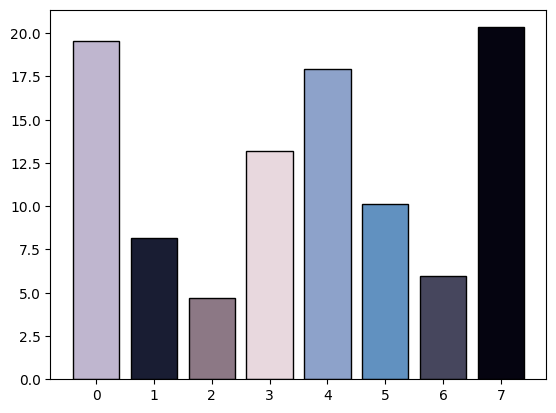

In [17]:
# Se genera gráfico de barras mostrando los colores y en que porcentaje se encuentran

plt.bar(x = range(len(df['labels'])),
        height = df['% count'],
        color = df['hex'].values,
        edgecolor = 'black');

## Bonus point: envuelva todo en una función

In [18]:
def analyze_colors(path, nc=8, rs=1):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (8,4))
    image = io.imread(path)
    h, w, ch = image.shape
    d = image.reshape (h*w, -1)
    m = MiniBatchKMeans(n_clusters = nc, random_state=rs)
    m.fit(d)
    center_m = m.cluster_centers_
    labels_m = m.labels_    
    hex_centers_m = list(map(rgb_to_hex, center_m))
    
    df_resumen = pd.DataFrame(data = {'labels':np.unique(labels_m), 'hex':hex_centers_m, 
                          'count':np.unique(labels_m, return_counts = True)[1]})
    
    color_total = df_resumen['count'].sum()
    porc_list=[]
    for i in df_resumen['count']:
        a = round((i/color_total)* 100, 3)
        porc_list.append(a)
    
    se = pd.Series(porc_list)
    df_resumen['% count'] = se
    
    ax2 = plt.bar(x = range(len(df_resumen['labels'])), height = df_resumen['% count'], color = df_resumen['hex'].values, edgecolor = 'black')
    ax1.imshow(image) 
    ax1.axis('off')

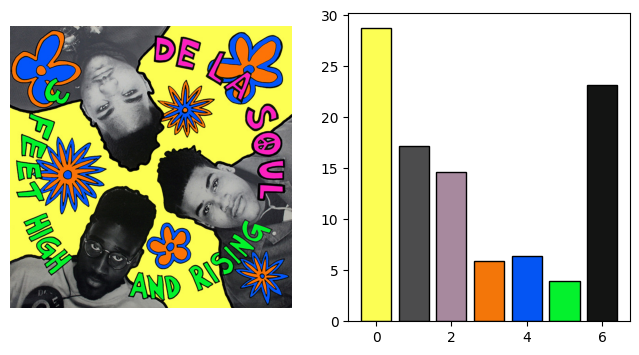

In [19]:
analyze_colors('album_covers/de-la-soul-3-feets-and-rising.jpg', 7)

# Evaluación del cluster

In [49]:
test_img = io.imread('album_covers/deafheaven-sunbather.jpg');
test_img = test_img.reshape(test_img.shape[0]*test_img.shape[1], -1)

In [65]:
n = 2
kmeans = MiniBatchKMeans(n_clusters=n, random_state = 1, batch_size=100).fit(test_img)

In [66]:
print(f'Silhouette Score KMeans - K = {n}: {silhouette_score(test_img, kmeans.labels_, sample_size=10000, random_state=1)}')

Silhouette Score KMeans - K = 2: 0.8783872648268454


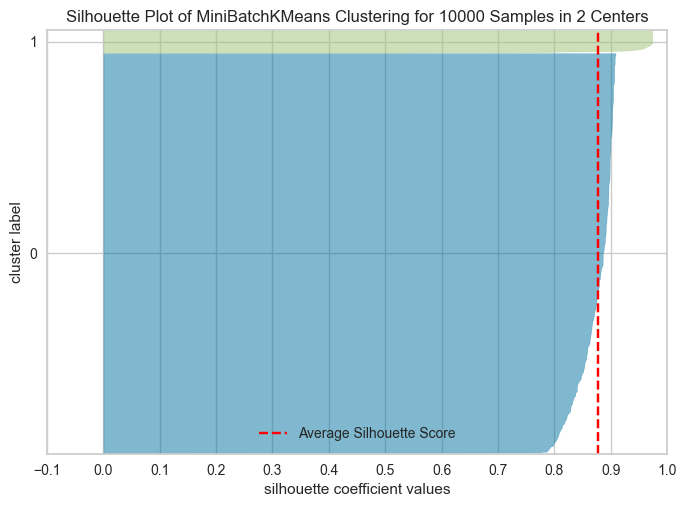

<Axes: title={'center': 'Silhouette Plot of MiniBatchKMeans Clustering for 10000 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [71]:
from yellowbrick.cluster import SilhouetteVisualizer

ipx = np.random.choice(len(test_img), size=10000, replace=False)

sample_test_img = test_img[ipx]

visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', is_fitted=True, force_model=True)
visualizer.fit(sample_test_img)
visualizer.show()

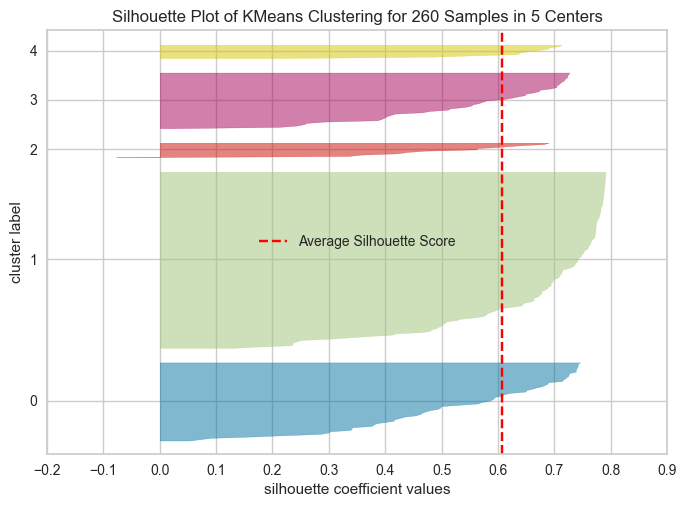

In [70]:
from sklearn.cluster import KMeans

from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.datasets import load_nfl

# Load a clustering dataset
X, y = load_nfl()

# Specify the features to use for clustering
features = ['Rec', 'Yds', 'TD', 'Fmb', 'Ctch_Rate']
X = X.query('Tgt >= 20')[features]

# Instantiate the clustering model and visualizer
model = KMeans(5, random_state=42)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick', force_model=True)

visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show();      # Finalize and render the figure

In [29]:
cluster_number = [2, 4, 7, 10, 20]
for n in cluster_number:
    kmeans = MiniBatchKMeans(n_clusters=n, random_state = 1).fit(test_img)
    print(f'Silhouette Score KMeans - K = {n}: {silhouette_score(test_img, kmeans.labels_, sample_size=100, random_state=1)}')  

Silhouette Score KMeans - K = 2: 0.8816479137269329
Silhouette Score KMeans - K = 4: 0.5642189694864873
Silhouette Score KMeans - K = 7: 0.4567939907218785
Silhouette Score KMeans - K = 10: 0.47031195286468075
Silhouette Score KMeans - K = 20: 0.3593947411338184
